In [1177]:
import pandas as pd
import numpy as np

## Dataset

Hofmann, H. (1994). Statlog (German Credit Data) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5NC77.

Downloaded from: https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data

In [1178]:
# Class: 1= Good, 2= Bad
cols = ["status", "duration", "history", "purpose", "amount", "savings", "employment", "installment_percent", "personal", "debtors", "residence_since", "property", "age", "other_plans", "housing", "existing_credits", "job", "liable", "telephone", "foreigner", "class"]
df = pd.read_csv("datasets/german/german.data", names=cols, sep=r'\s+')
df.head()

,status,duration,history,purpose,amount,savings,employment,installment_percent,personal,debtors,...,property,age,other_plans,housing,existing_credits,job,liable,telephone,foreigner,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## Data Preprocessing

### Categorical Variable Preprocessing

In [1179]:
# Class: True= bad
df["class"] = (df["class"].values == 2)
df.head()

,status,duration,history,purpose,amount,savings,employment,installment_percent,personal,debtors,...,property,age,other_plans,housing,existing_credits,job,liable,telephone,foreigner,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,False
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,True
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,False
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,False
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,True


In [1180]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,duration,amount,installment_percent,residence_since,age,existing_credits,liable,class,status_A12,status_A13,...,property_A124,other_plans_A142,other_plans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreigner_A202
0,6,1169,4,4,67,2,1,False,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,True,True,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,False,False,False,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,True,False,False,...,True,False,True,False,True,False,True,False,False,False


### Splitting the Dataset and Feature Scaling

In [1181]:
from sklearn.model_selection import train_test_split
y = df["class"]
X = df.drop(["class"], axis=1)
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

In [1182]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

In [1183]:
val_X, test_X = np.split(test_X, 2)
val_y, test_y = np.split(test_y, 2)

## Modelling

In [1184]:
corr_matrix = df.corr()
corr_matrix["class"].sort_values(ascending=False)

class                  1.000000
duration               0.214927
amount                 0.154739
history_A31            0.134448
property_A124          0.125750
status_A12             0.119581
employment_A72         0.106397
housing_A153           0.081556
personal_A92           0.075493
installment_percent    0.072404
purpose_A46            0.070088
debtors_A102           0.062728
other_plans_A142       0.050523
history_A32            0.043722
job_A174               0.040559
purpose_A49            0.036129
purpose_A410           0.028058
savings_A62            0.022255
purpose_A42            0.020971
purpose_A45            0.020828
history_A33            0.012325
property_A123          0.011121
employment_A73         0.010603
purpose_A44            0.008016
property_A122          0.007238
residence_since        0.002967
liable                -0.003015
job_A173              -0.013559
personal_A94          -0.019630
job_A172              -0.021822
telephone_A192        -0.036466
purpose_

### Logistic Regression

In [1185]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(train_X, train_y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

#### Logistic Regression Score

In [1186]:
log_reg.score(test_X, test_y)

0.79

### Random Forest Classifier

In [1187]:
from sklearn.ensemble import RandomForestClassifier
forest_cls = RandomForestClassifier()
forest_cls.fit(train_X, train_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

#### Random Forest Classifier Score

In [1188]:
forest_cls.score(test_X, test_y)

0.77

### Neural Net Classifier

In [1189]:
import tensorflow as tf

In [1190]:
# https://keras.io/guides/sequential_model/
# https://keras.io/guides/training_with_built_in_methods/
nn_cls = tf.keras.Sequential([
    tf.keras.layers.Dense(20, activation='relu', name="layer1"),
    tf.keras.layers.Dense(20, activation='relu', name="layer2"),
    tf.keras.layers.Dense(20, activation='relu', name="layer3"),
    tf.keras.layers.Dense(20, activation='relu', name="layer4"),
    tf.keras.layers.Dense(1 , activation='sigmoid', name="output-layer")
])
nn_cls.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [1191]:
history = nn_cls.fit(train_X, train_y, batch_size=64, epochs=23, validation_data=(val_X, val_y), verbose=0)

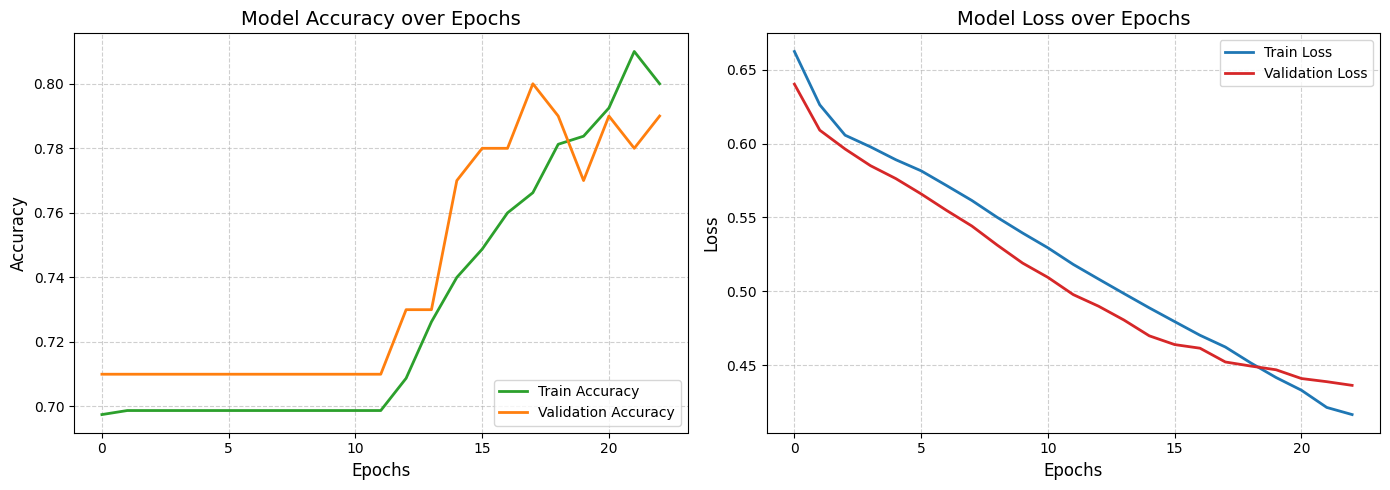

In [1192]:
# From Google AI Overview
import matplotlib.pyplot as plt
# 2. Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='#2ca02c', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)
ax1.set_title('Model Accuracy over Epochs', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='#d62728', linewidth=2)
ax2.set_title('Model Loss over Epochs', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [1193]:
results = nn_cls.evaluate(val_X, val_y, batch_size=128)
print(results)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7900 - loss: 0.4364
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7900 - loss: 0.4364
[0.4363801181316376, 0.7900000214576721]


### Model Costs

In [1194]:
# tn=(0,0), fn=(1,0), tp=(1,1), fp=(0,1)
# tn fp
# fn tp
from sklearn.metrics import confusion_matrix

pred_y_log    = log_reg.predict(test_X)
pred_y_forest = forest_cls.predict(test_X)
pred_y_nn     = nn_cls.predict(test_X)
threshold     = 0.2
pred_y_nn     = (pred_y_nn > threshold)

cm_log = confusion_matrix(test_y,    pred_y_log)
cm_forest = confusion_matrix(test_y, pred_y_forest)
cm_nn = confusion_matrix(test_y,     pred_y_nn)

print("Confusion (log):\n",    cm_log)
print("Confusion (forest):\n", cm_forest)
print("Confusion (nn):\n",     cm_nn)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Confusion (log):
 [[64  6]
 [15 15]]
Confusion (forest):
 [[66  4]
 [19 11]]
Confusion (nn):
 [[36 34]
 [ 7 23]]


In [1195]:
total_cost_log    = (cost*cm_log)[0][1]    + (cost*cm_log)[1][0]
total_cost_forest = (cost*cm_forest)[0][1] + (cost*cm_forest)[1][0]
total_cost_nn     = (cost*cm_nn)[0][1]     + (cost*cm_nn)[1][0]
print("Total cost log: ",    total_cost_log)
print("Total cost forest: ", total_cost_forest)
print("Total cost nn: ",     total_cost_nn, " with a probability threshold of ", threshold, " at the cost of turning away good customers.")

Total cost log:  81
Total cost forest:  99
Total cost nn:  69  with a probability threshold of  0.2  at the cost of turning away good customers.
